# Study 774 — Nintendo-Direct 🎮

*For the curious.* Gaming Twitter *knows* you buy Nintendo into a Direct — the hype builds, the stock rips, and then you either ride a great showing or sell the news. We put 25 flagship Nintendo Directs (2013→2025) on the stand and asked the tape two plain questions: **does NTDOY rally into the broadcast?** and **does it move after?** The answer is a quiet double bust.

## The claim, and the honest catch

A Nintendo Direct is Nintendo's ~40-minute video showcase — its biggest owned-media catalyst. The folklore: buy the hype in, sell the news out. The catch: a Direct is usually **announced only ~1-3 days ahead**, so *buy 2 weeks before* isn't really something you could have traded — you'd have needed to know the date. We test the run-up anyway (it's the folklore) and measure NTDOY's **abnormal** return (NTDOY − SPY, total-return) so we're not just measuring the market.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from nintendo_direct import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching NTDOY + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} Directs resolved")


panel loaded; 25 of 25 Directs resolved


## The Direct calendar we test (hardcoded from Wikipedia / Nintendo Life)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['air_date', 'label'])

,air_date,label
0,2013-06-11,E3 2013
1,2013-12-18,Dec 2013 (Wii U / 3DS)
2,2014-02-13,Feb 2014 (Wii U / 3DS)
3,2014-06-10,E3 2014
4,2015-06-16,E3 2015
5,2016-03-03,Mar 2016 (Wii U / 3DS)
6,2017-06-13,E3 2017
7,2017-09-13,Sep 2017 (Switch / 3DS)
8,2018-03-08,Mar 2018
9,2018-06-12,E3 2018


## The picture: mean cumulative abnormal return around the Direct

Offset 0 is the Direct. Left of zero is the *run-up* (the supposed hype rally); right of zero is the *fade/pop* window.

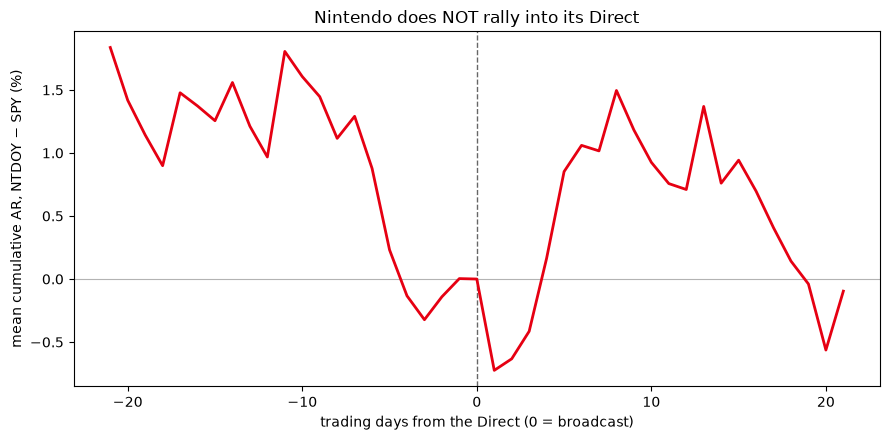

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#e60012', lw=2)
ax.set_xlabel('trading days from the Direct (0 = broadcast)')
ax.set_ylabel('mean cumulative AR, NTDOY − SPY (%)')
ax.set_title('Nintendo does NOT rally into its Direct')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | hit rate |
|---|--:|--:|--:|
| 2-week run-up | -1.47% | -1.55 | 10/25 |
| 1-month run-up | -1.20% | -0.69 | 12/25 |
| 2-week fade | +0.93% | +0.77 | 13/25 |
| 1-month fade | -0.10% | -0.05 | 13/25 |

The bullish folklore just **isn't there**: the run-up sign is mildly *negative* (-1.47%) but nowhere near significant (*t* = -1.55, hit rate 10/25 — a coin flip). And the 'sell the news' fade? A clean zero (both cuts |*t*| < 0.8).

In [4]:
rows = [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk fade','post_s'),('1mo fade','post_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<12s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

2wk run-up   n=25  mean=-1.474%  t=-1.552  hit 10/25
1mo run-up   n=25  mean=-1.203%  t=-0.688  hit 12/25
2wk fade     n=25  mean=+0.925%  t=+0.774  hit 13/25
1mo fade     n=25  mean=-0.096%  t=-0.053  hit 13/25


## So what?

The famous *buy the hype into a Nintendo Direct* trade is folklore: NTDOY doesn't rally in (a mild, insignificant dip if anything) and doesn't reliably move after. On top of the missing signal, you couldn't have traded a clean 2-week run-up anyway (Directs are announced ~1-3 days ahead) and NTDOY is a thin OTC ADR. Verdict: **None signal, Mirage tradability.** The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control.